In [1]:
# AdaDetect Benchmark Notebook

# =========================
# 1. INSTALL (run once)
# =========================
# !pip install medmnist torchvision

# =========================
# 2. IMPORTS
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
import medmnist
from medmnist import INFO

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from procedure import AdaDetectERM

np.random.seed(42)

In [2]:


# =========================
# 3. DATA LOADERS
# =========================

def load_mnist():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

    X = dataset.data.numpy().reshape(len(dataset), -1) / 255.0
    y = dataset.targets.numpy()

    return X, y


def load_medmnist(name):
    info = INFO[name]
    DataClass = getattr(medmnist, info['python_class'])

    dataset = DataClass(split='train', download=True)

    X = dataset.imgs.reshape(len(dataset), -1) / 255.0
    y = dataset.labels

    # Handle multi-label (ChestMNIST)
    if len(y.shape) > 1 and y.shape[1] > 1:
        y = (y.sum(axis=1) > 0).astype(int)
    else:
        y = y.squeeze()

    return X, y


def get_datasets():
    return {
        "mnist": load_mnist(),
        "derma_mnist": load_medmnist("dermamnist"),
        "chest_mnist": load_medmnist("chestmnist"),
    }


In [3]:

# =========================
# 4. PREPROCESSING
# =========================

def preprocess(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)


def split_null_signal(X, y, null_class=0):
    mask_null = (y == null_class)

    xnull = X[mask_null]
    x = X

    is_signal = ~mask_null

    return x, xnull, is_signal


In [12]:

# =========================
# 5. CLASSIFIERS
# =========================

# Optional: CNN classifier (if you had one before)
import torch
import torch.nn as nn
import torch.optim as optim

class CNNClassifier:
    def __init__(self, input_dim, epochs=5, lr=1e-3, batch_size=64):
        self.input_dim = input_dim
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        ).to(self.device)

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        y = torch.tensor(y, dtype=torch.long).to(self.device)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        self.model.train()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            out = self.model(X)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            logits = self.model(X)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()


def get_classifiers(input_dim):
    return {
        "knn": KNeighborsClassifier(3),
        "svm": SVC(probability=True),
        "decision_tree": DecisionTreeClassifier(max_depth=5),
        "random_forest": RandomForestClassifier(n_estimators=100),
        "mlp": MLPClassifier(max_iter=500),
        "adaboost": AdaBoostClassifier(),
        "naive_bayes": GaussianNB(),
        # "gaussian_process": GaussianProcessClassifier(1.0 * RBF(1.0)),
        "cnn": CNNClassifier(input_dim=input_dim)
    }


In [13]:

# =========================
# 6. METRICS
# =========================

def compute_fdr_power(rejection_set, is_signal):
    R = len(rejection_set)

    if R == 0:
        return 0.0, 0.0

    rejected = np.zeros_like(is_signal, dtype=bool)
    rejected[rejection_set] = True

    V = np.sum(rejected & ~is_signal)
    S = np.sum(rejected & is_signal)

    FDR = V / R
    power = S / np.sum(is_signal)

    return FDR, power


In [14]:

# =========================
# 7. RUN ADaDETECT
# =========================

def run_adadetect(model, x, xnull, is_signal, level=0.1):
    proc = AdaDetectERM(scoring_fn=model, split_size=0.5)

    rejection_set = proc.apply(x=x, level=level, xnull=xnull)

    fdr, power = compute_fdr_power(rejection_set, is_signal)

    return {
        "n_rejections": len(rejection_set),
        "fdr": fdr,
        "power": power
    }


In [15]:

# =========================
# 8. BENCHMARK
# =========================

def benchmark():
    datasets = get_datasets()
    classifiers = get_classifiers(1)

    results = []

    for dname, (X, y) in datasets.items():
        print(f"\nDataset: {dname}")

        X = preprocess(X)

        # Define null class
        null_class = 0

        x, xnull, is_signal = split_null_signal(X, y, null_class)

        # Subsample for speed (optional)
        max_samples = 5000
        if len(x) > max_samples:
            idx = np.random.choice(len(x), max_samples, replace=False)
            x = x[idx]
            is_signal = is_signal[idx]

        if len(xnull) > max_samples:
            idx_null = np.random.choice(len(xnull), max_samples, replace=False)
            xnull = xnull[idx_null]

        for cname, model in classifiers.items():
            print(f"  Model: {cname}")

            try:
                res = run_adadetect(model, x, xnull, is_signal)

                results.append({
                    "dataset": dname,
                    "model": cname,
                    **res
                })

            except Exception as e:
                print(f"    Failed: {e}")

    return pd.DataFrame(results)

In [16]:


# =========================
# 9. ANALYSIS
# =========================

def analyze(df):
    print("\n=== RESULTS ===")
    print(df.groupby(["dataset", "model"])[["fdr", "power"]].mean())

    for dname in df["dataset"].unique():
        subset = df[df["dataset"] == dname]

        plt.figure()
        plt.scatter(subset["fdr"], subset["power"])

        for _, row in subset.iterrows():
            plt.text(row["fdr"], row["power"], row["model"])

        plt.xlabel("FDR")
        plt.ylabel("Power")
        plt.title(f"FDR vs Power ({dname})")
        plt.show()


Using downloaded and verified file: C:\Users\h4sor\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\h4sor\.medmnist\chestmnist.npz

Dataset: mnist
  Model: knn
  Model: svm
  Model: decision_tree
  Model: random_forest
  Model: mlp
  Model: adaboost
  Model: naive_bayes
  Model: cnn
    Failed: mat1 and mat2 shapes cannot be multiplied (10000x784 and 1x128)

Dataset: derma_mnist
  Model: knn
  Model: svm
  Model: decision_tree
  Model: random_forest
  Model: mlp
  Model: adaboost
  Model: naive_bayes
  Model: cnn
    Failed: mat1 and mat2 shapes cannot be multiplied (5228x2352 and 1x128)

Dataset: chest_mnist
  Model: knn
  Model: svm
  Model: decision_tree
  Model: random_forest
  Model: mlp
  Model: adaboost
  Model: naive_bayes
  Model: cnn
    Failed: mat1 and mat2 shapes cannot be multiplied (10000x784 and 1x128)

=== RESULTS ===
                                fdr     power
dataset     model                            
chest_mnist adaboost       0.000000  0.0

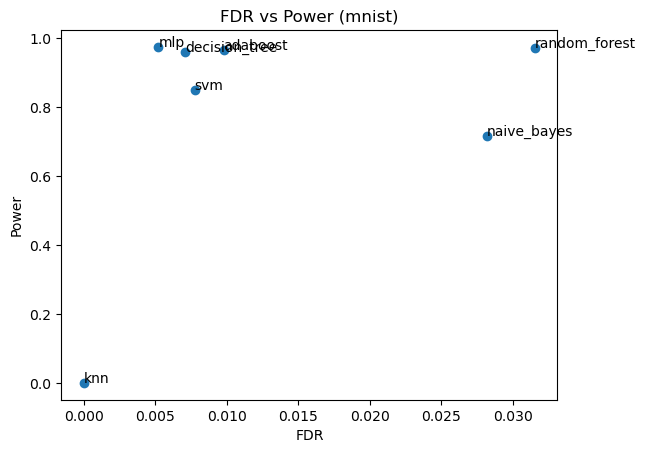

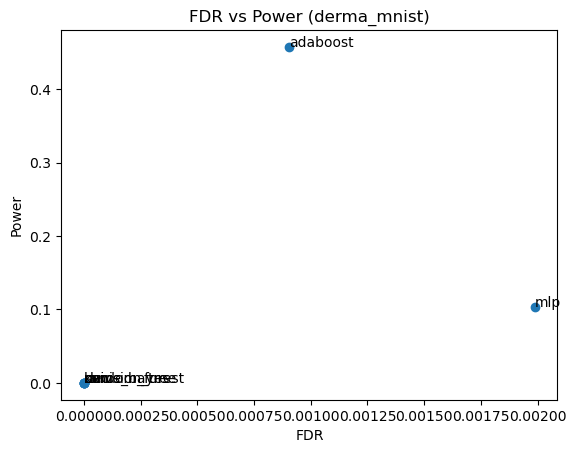

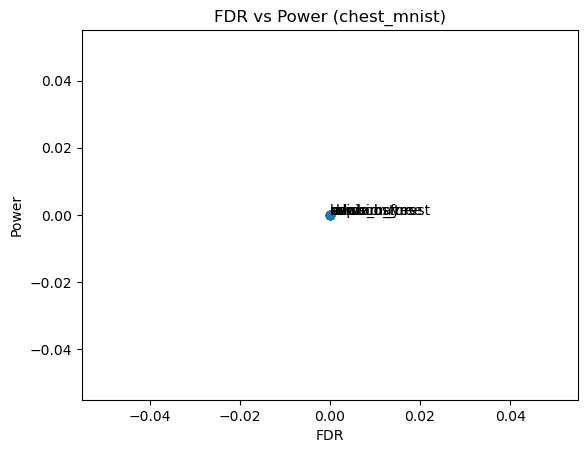

In [17]:

# =========================
# 10. RUN EVERYTHING
# =========================

df = benchmark()
analyze(df)

